<a href="https://colab.research.google.com/github/Jana-Alothman/GP1/blob/main/Arabic_Readability_Classification_On_BAREC_Corpus_Using_Temp_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Arabic Readability Classification On BAREC Corpus Using Decision Tree Model**

This notebook implements a **Decision Tree classifier** for Arabic readability classification using the BAREC Corpus.

The experiments use TF-IDF text features and evaluate two classification settings: **19-level** and **5-level** readability.

For each task:
1. A baseline Decision Tree is trained using the default scikit-learn settings.
2. Hyperparameters are selected using the predefined **development/validation set**.
3. The training and development sets are kept separate during model selection: the model is fitted on the training set and evaluated on the development set.
4. After selecting the best hyperparameters, two tuned models are trained on the training set and evaluated on the test set:
   - `class_weight="balanced"`
   - `class_weight=None`
5. The test set is used only for the baseline/final model evaluation, not for hyperparameter selection.

# **Data Collection**

**Dataset Source:**

In this project, the dataset used for Arabic readability assessment was obtained from BAREC Corpus v1.0 on Hugging Face.

---
**Research paper:**

A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.

---

**Data Fields:**
- ID: Unique sentence identifier.
- Sentence: The sentence text.
- Word_Count: Number of words in the sentence.
- Word: Simply tokenized and dediacritized sentences.
- Lex: Each word is replaced by its predicited lemma (dediacritized).
- D3Tok: We tokenize words into their base and clitics forms.
- D3Lex: We replace the base forms in D3Tok with the predicited lemmas.
- Readability_Level: The readability level in 19-levels scheme, ranging from 1-alif to 19-qaf.
- Readability_Level_19: The readability level in 19-levels scheme, ranging from 1 to 19.
- Readability_Level_7: The readability level in 7-levels scheme, ranging from 1 to 7.
- Readability_Level_5: The readability level in 5-levels scheme, ranging from 1 to 5.
- Readability_Level_3: The readability level in 3-levels scheme, ranging from 1 to 3.
- Annotator: The annotator ID (A1-A5 or IAA).
- Document: Source document file name.
- Source: Document source.
- Book: Book name.
- Author: Author name.
- Domain: Domain (Arts & Humanities, STEM or Social Sciences).
- Text_Class: Readership group (Foundational, Advanced or Specialized).

---
**Supported Tasks:**

The dataset supports multi-class readability classification in the following formats:

- 19 levels (default)
- 7 levels
- 5 levels
- 3 levels

---
**Data Splits:**
- The BAREC dataset has three splits: Train (80%), Dev (10%), and Test (10%).
- The splits are in the document level.
- The splits are balanced accross Readability Levels, Domains, and Text Classes.



In [2]:
# Install required libraries for dataset loading and processing.

!pip install datasets pandas

In [3]:
# Load the BAREC dataset and display dataset splits and columns.

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

# Load each split separately
train_df = dataset["train"].to_pandas()
dev_df = dataset["dev"].to_pandas()
test_df = dataset["test"].to_pandas()
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

print("\nDataset Columns:\n")
print(full_df.columns)

print("\nSample Data:\n")
full_df.head()

Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)

Dataset Columns:

Index(['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex',
       'Readability_Level', 'Readability_Level_19', 'Readability_Level_7',
       'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document',
       'Source', 'Book', 'Author', 'Domain', 'Text_Class'],
      dtype='object')

Sample Data:



,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [4]:
# Save the complete dataset as a CSV file.

full_df.to_csv("BAREC_full.csv", index=False)

In [5]:
# Create a filtered version containing selected columns only.

filtered_full_df = full_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_train_df = train_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_dev_df = dev_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_test_df = test_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_full_df.to_csv("BAREC_full_filtered.csv", index=False)
filtered_full_df.head()

,Word,Word_Count,Domain,Text_Class,Readability_Level_19,Readability_Level_5
0,مجلة كل الأولاد وكل البنات,5,Arts & Humanities,Foundational,7,1
1,ماجد,1,Arts & Humanities,Foundational,1,1
2,الأربعاء 21 يناير 1987,4,Arts & Humanities,Foundational,8,2
3,الموافق 21 جمادى الأول 1407ه,6,Arts & Humanities,Foundational,7,1
4,السنة الثامنة,2,Arts & Humanities,Foundational,5,1


**Feature Selection Justification**

Only the **Word** column was used as the input feature because this study aims to classify readability using textual information represented by TF-IDF features.

The remaining columns were excluded for the following reasons:

---

**Text Variations (Sentence, Lex, D3Tok, D3Lex)**

These columns are different linguistic transformations of the same sentence.

- They represent the same original text in different formats  

---

**Alternative Readability Levels (3, 7-level schemes)**

These columns represent the same target variable (readability) but on different scales.

- They contain overlapping information with the main target (19 & 5 -level scales)


---

**Metadata Columns (ID, Annotator, Document, Source, Book, Author)**

These columns are not useful for prediction.

- They are administrative or contextual only
- They do not contribute to readability prediction

---

**Final Selected Features**

The final dataset used for modeling includes:

- **Word** → main input text
- **Word_Count** → length-based feature
- **Domain** → topic/category information
- **Text_Class** → readership group
- **Readability_Level_19** → target label
- **Readability_Level_5** → target label

In [6]:
# Download both the full and filtered datasets.

from google.colab import files

#files.download("BAREC_full.csv")
#files.download("BAREC_full_filtered.csv")

# **Data Preprocessing**

In this stage, we perform preprocessing on the **filtered dataset** to ensure it is clean, consistent, and ready for machine learning.

## 1. Checking Missing Values

We first check whether the dataset contains any missing values.

Even if the dataset is clean, this step ensures there are no hidden nulls that could affect model training.

In [7]:
filtered_full_df.isnull().sum()

,0
Word,0
Word_Count,0
Domain,0
Text_Class,0
Readability_Level_19,0
Readability_Level_5,0


**Interpretation:** The dataset shows no missing values across all selected features, indicating that the data is complete and well-structured.

## 2. Checking Duplicate Rows

We check for duplicate rows to make sure the model does not learn repeated examples that could bias training.

In [8]:
beforeFull = filtered_full_df.duplicated().sum()
beforeTrain = filtered_train_df.duplicated().sum()
beforeDev = filtered_dev_df.duplicated().sum()
beforeTest = filtered_test_df.duplicated().sum()

print("Before dropping duplicates (Full) = " , beforeFull)
print("Before dropping duplicates (Train) = " , beforeTrain)
print("Before dropping duplicates (Dev) = " , beforeDev)
print("Before dropping duplicates (Test) = " , beforeTest)

Before dropping duplicates (Full) =  3542
Before dropping duplicates (Train) =  2670
Before dropping duplicates (Dev) =  195
Before dropping duplicates (Test) =  213


In [9]:
afterFull = filtered_full_df.drop_duplicates().duplicated().sum()
afterTrain = filtered_train_df.drop_duplicates().duplicated().sum()
afterDev = filtered_dev_df.drop_duplicates().duplicated().sum()
afterTest = filtered_test_df.drop_duplicates().duplicated().sum()

print("After dropping duplicates (Full) = " , afterFull)
print("After dropping duplicates (Train) = " , afterTrain)
print("After dropping duplicates (Dev) = " , afterDev)
print("After dropping duplicates (Test) = " , afterTest)

After dropping duplicates (Full) =  0
After dropping duplicates (Train) =  0
After dropping duplicates (Dev) =  0
After dropping duplicates (Test) =  0


**Interpretation:** 3,542 duplicate rows were found in the dataset, indicating repeated samples. These duplicates were removed to prevent bias and ensure the model does not learn from repeated instances of the same data.

## 3. Checking Label Distribution

We analyze the distribution of the 19-level and 5-level readability classes to understand whether the dataset is balanced or imbalanced.

In [10]:
filtered_full_df["Readability_Level_19"].value_counts().sort_index()

,count
Readability_Level_19,
1,409
2,437
3,1462
4,751
5,3443
6,1534
7,5438
8,5683
9,2023


In [11]:
filtered_full_df["Readability_Level_5"].value_counts().sort_index()

,count
Readability_Level_5,
1,13474
2,22383
3,18510
4,13234
5,1840


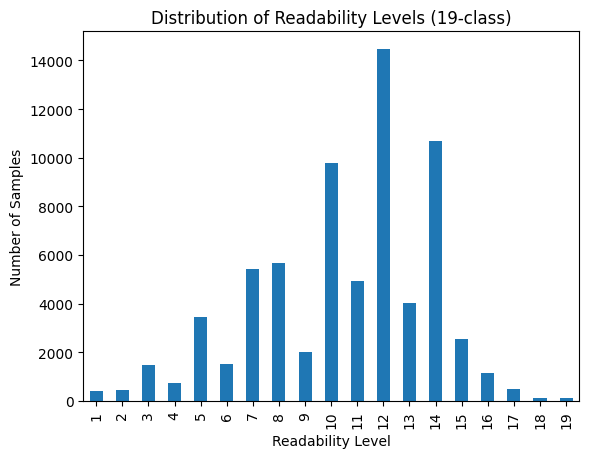

In [12]:
import matplotlib.pyplot as plt

full_df["Readability_Level_19"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (19-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

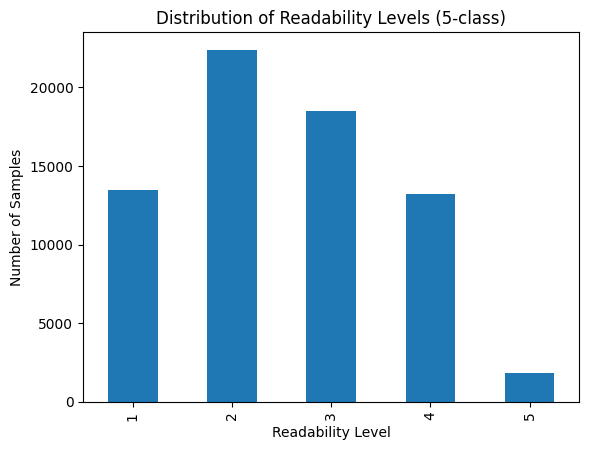

In [13]:
import matplotlib.pyplot as plt

full_df["Readability_Level_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (5-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation:** The dataset shows a clear class imbalance across the 19 and 5 readability levels. Some classes contain a significantly higher number of samples, while higher levels have very few instances. This imbalance may affect model performance and bias predictions toward majority classes.

#**Model Training**

## **Decision Tree Model**

### Why Decision Tree?

A Decision Tree is a supervised machine-learning algorithm that learns a sequence of feature-based decision rules to assign each sample to a class.

For this project, TF-IDF converts the Arabic text into numerical features, and the Decision Tree learns which textual features are useful for separating the readability levels.

Decision Trees were selected because they:
- can model non-linear decision boundaries,
- do not require feature scaling,
- support multi-class classification directly,
- provide interpretable rule-based decisions,
- and support `class_weight`, allowing us to study the effect of class imbalance.

Because text represented with TF-IDF is high-dimensional, an unrestricted Decision Tree can overfit. Therefore, the baseline is kept completely default as required, while `max_depth`, `min_samples_split`, and `min_samples_leaf` are tuned using cross-validation.

### **Decision Tree Setup and Hyperparameter Search Space**

The same hyperparameter search space is used for both the **19-level** and **5-level** experiments.

`class_weight` is intentionally **not included** in the GridSearchCV search space. GridSearchCV first identifies the best structural Decision Tree hyperparameters. The exact same selected structural parameters are then used to compare:
- `class_weight="balanced"`
- `class_weight=None`

This gives a fair comparison of the effect of class weighting without changing the tree structure between the two tuned variants.

The search space is:

- `criterion`: `gini` and `entropy`  
  These are the two standard impurity measures used to choose splits.

- `max_depth`: `None`, `10`, `20`, `30`  
  `None` allows the tree to grow without a depth restriction, while 10, 20, and 30 test progressively more flexible trees and help control overfitting.

- `min_samples_split`: `2`, `5`, `10`  
  The default value 2 is retained as a reference, while larger values regularize the model by requiring more samples before creating a new split.

- `min_samples_leaf`: `1`, `2`, `4`  
  The default value 1 is retained, while larger values prevent leaves from being formed from very small numbers of training samples.

This produces **72 combinations** and, with 5-fold cross-validation, **360 fits per readability task**.

In [14]:
# Import TF-IDF vectorizer for converting text into numerical feature vectors
from sklearn.feature_extraction.text import TfidfVectorizer

# Define input text
dt_X_train = filtered_train_df["Word"]
dt_X_dev = filtered_dev_df["Word"]
dt_X_test = filtered_test_df["Word"]

# Use unigrams and bigrams, matching the shared project methodology
dt_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

# Fit only on training data to avoid information leakage
dt_X_train_tfidf = dt_vectorizer.fit_transform(dt_X_train)
dt_X_dev_tfidf = dt_vectorizer.transform(dt_X_dev)
dt_X_test_tfidf = dt_vectorizer.transform(dt_X_test)

print("Train TF-IDF shape:", dt_X_train_tfidf.shape)
print("Validation TF-IDF shape:", dt_X_dev_tfidf.shape)
print("Test TF-IDF shape:", dt_X_test_tfidf.shape)

Train TF-IDF shape: (54845, 520826)
Validation TF-IDF shape: (7310, 520826)
Test TF-IDF shape: (7286, 520826)


**ngram_range Justification**


The parameter `ngram_range=(1,2)` was selected to include both **unigrams** (single words) and **bigrams** (pairs of consecutive words). While unigrams capture the importance of individual words, bigrams preserve short contextual information that may improve the model's ability to distinguish different readability levels.

This configuration is widely adopted in text classification tasks because it provides a good balance between capturing contextual information and maintaining computational efficiency.

---

##**Model Evaluation Function**

**Evaluation Metrics Overview:**

The model is evaluated using multiple metrics to properly reflect its performance on an ordinal readability classification task.

- **Quadratic Weighted Kappa (QWK):** Primary metric that measures agreement between predicted and actual labels while penalizing larger errors more heavily.
- **Accuracy:** Measures exact match between predicted and true labels.
- **Acc ±1:** Considers predictions correct if they are within one level of the true label.
- **Macro F1-score:** Evaluates performance equally across all classes, making it suitable for imbalanced datasets.
- **Precision & Recall:** Measure class-level prediction quality and coverage.
- **Confusion Matrix:** Provides detailed insight into misclassification patterns.
- **MAE/Distance (Mean Absolute Error)**: The average absolute difference between predicted and true values. Treats all errors equally. Lower is better.
- **RMSE (Root Mean Square Error):** The square root of the average squared difference between predicted and true values. Penalizes large errors more heavily than MAE. Lower is better.
- **R² Score:** Indicates how well predictions explain variance in readability levels, though less common for classification tasks.

In [15]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    cohen_kappa_score,
    r2_score
)

import numpy as np


def evaluate_dt_model(y_true, y_pred, dataset_name):
    """Evaluate a Decision Tree model using the project evaluation metrics."""

    accuracy = accuracy_score(y_true, y_pred)
    adj_accuracy = np.mean(np.abs(y_true - y_pred) <= 1)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("=" * 60)
    print(dataset_name)
    print("=" * 60)

    print(f"Accuracy:                      {accuracy:.4f}")
    print(f"Adjacent Accuracy (±1):        {adj_accuracy:.4f}")
    print(f"Quadratic Weighted Kappa:      {qwk:.4f}")
    print(f"Macro F1-score:                {macro_f1:.4f}")
    print(f"Weighted Precision:            {precision:.4f}")
    print(f"Weighted Recall:               {recall:.4f}")
    print(f"Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"Root Mean Squared Error:       {rmse:.4f}")
    print(f"R² Score:                      {r2:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, zero_division=0))

**How to call the function?**

```python
evaluate_dt_model(
    dt_y_test_19,
    dt_baseline_19_test_pred,
    "Baseline Decision Tree (19-Level) - Test Set"
)
```

##**Confusion Matrix Function**

In [16]:
# Import libraries for confusion matrix visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title):
    """
    Plot a confusion matrix for a classification model.
    """

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

**How to call the function?**

```python
plot_confusion_matrix(
    dt_y_test_19,
    dt_baseline_19_test_pred,
    labels=list(range(1, 20)),
    title="Confusion Matrix - Baseline Decision Tree (19-Level)"
)
```

---

## **Decision Tree Baseline Model (19-Level)**

In [17]:
# Define target labels for the 19-level classification task
dt_y_train_19 = filtered_train_df["Readability_Level_19"]
dt_y_dev_19 = filtered_dev_df["Readability_Level_19"]
dt_y_test_19 = filtered_test_df["Readability_Level_19"]

In [18]:
from sklearn.tree import DecisionTreeClassifier

# Baseline model: all DecisionTreeClassifier hyperparameters remain at their defaults
dt_baseline_19 = DecisionTreeClassifier()

print(dt_baseline_19.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


In [19]:
# Train the baseline model
dt_baseline_19.fit(
    dt_X_train_tfidf,
    dt_y_train_19
)

DecisionTreeClassifier()

In [20]:
# Generate test predictions
dt_baseline_19_test_pred = dt_baseline_19.predict(dt_X_test_tfidf)

In [21]:
evaluate_dt_model(
    dt_y_test_19,
    dt_baseline_19_test_pred,
    "Baseline Decision Tree (19-Level) - Test Set"
)

Baseline Decision Tree (19-Level) - Test Set
Accuracy:                      0.2845
Adjacent Accuracy (±1):        0.4197
Quadratic Weighted Kappa:      0.3358
Macro F1-score:                0.2290
Weighted Precision:            0.2834
Weighted Recall:               0.2845
Mean Absolute Error (MAE):     2.5847
Root Mean Squared Error:       3.6821
R² Score:                      -0.2757

Classification Report:

              precision    recall  f1-score   support

           1       0.61      0.53      0.57        32
           2       0.43      0.33      0.38        36
           3       0.34      0.37      0.36       141
           4       0.15      0.30      0.20        86
           5       0.37      0.44      0.40       380
           6       0.24      0.22      0.23       139
           7       0.31      0.41      0.35       585
           8       0.24      0.40      0.30       541
           9       0.37      0.37      0.37       190
          10       0.31      0.46      0.38   

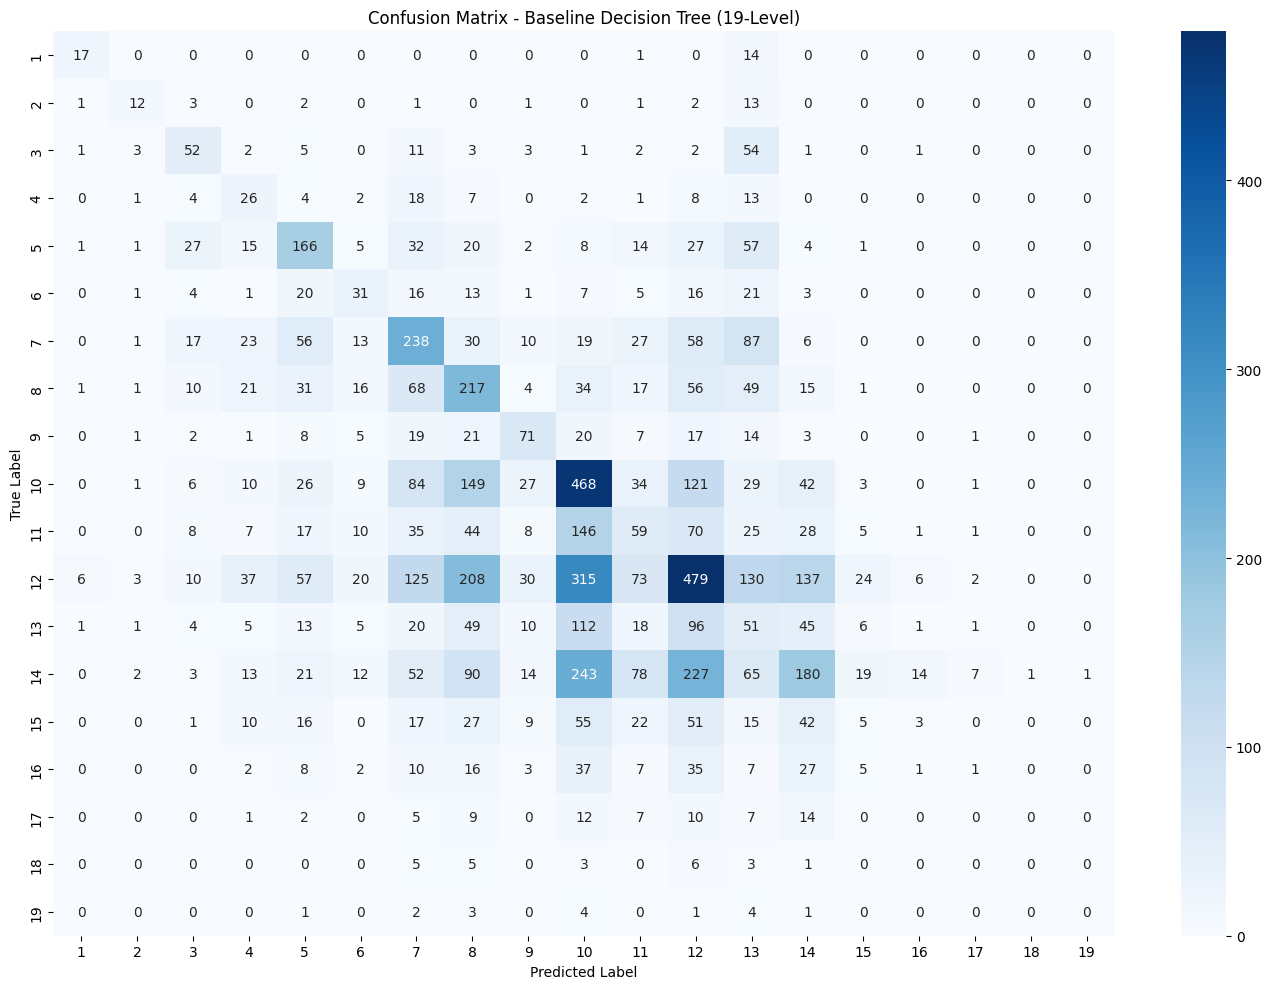

In [22]:
plot_confusion_matrix(
    dt_y_test_19,
    dt_baseline_19_test_pred,
    labels=list(range(1, 20)),
    title="Confusion Matrix - Baseline Decision Tree (19-Level)"
)

### **Decision Tree Baseline Findings (19-Level)**

The baseline Decision Tree achieved an accuracy of 28.45% and an adjacent accuracy of 41.97%. The model obtained a QWK of 0.3358 and a Macro F1-score of 0.2290. The MAE of 2.5847 indicates that predictions differed from the true readability level by approximately 2.58 levels on average. Performance was weaker for the highest readability levels, particularly classes 17–19.

## **Decision Tree Hyperparameter Tuning (19-Level)**

The hyperparameter search selected criterion="gini", max_depth=None, and min_samples_split=10, achieving a best validation accuracy of 29.58%. The main change from the baseline was increasing min_samples_split from 2 to 10, indicating that reducing very small splits provided better validation performance.

In [23]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.tree import DecisionTreeClassifier
from scipy.sparse import vstack
import numpy as np
import pandas as pd

# Focused Decision Tree search space: 2 x 2 x 2 = 8 combinations
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 20],
    "min_samples_split": [2, 10]
}

# Combine TRAIN and VALIDATION features only for GridSearchCV.
# PredefinedSplit tells GridSearchCV which rows are training and which are validation.
dt_X_train_dev = vstack([
    dt_X_train_tfidf,
    dt_X_dev_tfidf
])

dt_y_train_dev_19 = np.concatenate([
    dt_y_train_19,
    dt_y_dev_19
])

# -1 = training rows, 0 = validation rows
dt_test_fold_19 = np.concatenate([
    np.full(len(dt_y_train_19), -1),
    np.zeros(len(dt_y_dev_19), dtype=int)
])

dt_predefined_split_19 = PredefinedSplit(test_fold=dt_test_fold_19)

dt_base = DecisionTreeClassifier()

dt_grid_search_19 = GridSearchCV(
    estimator=dt_base,
    param_grid=dt_param_grid,
    cv=dt_predefined_split_19,
    scoring="accuracy",
    n_jobs=2,
    verbose=2,
    refit=False
)

dt_grid_search_19.fit(
    dt_X_train_dev,
    dt_y_train_dev_19
)

dt_best_params_19 = dt_grid_search_19.best_params_.copy()
dt_best_validation_accuracy_19 = dt_grid_search_19.best_score_

print("Best Parameters (19-Level):", dt_best_params_19)
print(f"Best Validation Accuracy (19-Level): {dt_best_validation_accuracy_19:.4f}")

# Optional compact table showing every candidate and its validation accuracy
dt_results_19 = pd.DataFrame(dt_grid_search_19.cv_results_)[
    ["params", "mean_test_score", "rank_test_score"]
].sort_values("rank_test_score")

display(dt_results_19)

Fitting 1 folds for each of 8 candidates, totalling 8 fits
Best Parameters (19-Level): {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10}
Best Validation Accuracy (19-Level): 0.2958


,params,mean_test_score,rank_test_score
1,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.295759,1
0,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.287278,2
5,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.264295,3
4,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.256361,4
2,"{'criterion': 'gini', 'max_depth': 20, 'min_sa...",0.241176,5
3,"{'criterion': 'gini', 'max_depth': 20, 'min_sa...",0.239535,6
6,"{'criterion': 'entropy', 'max_depth': 20, 'min...",0.228181,7
7,"{'criterion': 'entropy', 'max_depth': 20, 'min...",0.225445,8


## **Decision Tree Tuned Model (19-Level)**
### `class_weight="balanced"`

Tuned Decision Tree - Balanced (19-Level) - Test Set
Accuracy:                      0.2413
Adjacent Accuracy (±1):        0.3706
Quadratic Weighted Kappa:      0.3845
Macro F1-score:                0.1851
Weighted Precision:            0.2762
Weighted Recall:               0.2413
Mean Absolute Error (MAE):     3.0150
Root Mean Squared Error:       4.2024
R² Score:                      -0.6618

Classification Report:

              precision    recall  f1-score   support

           1       0.06      0.94      0.10        32
           2       0.27      0.25      0.26        36
           3       0.29      0.38      0.33       141
           4       0.11      0.36      0.16        86
           5       0.35      0.44      0.39       380
           6       0.20      0.24      0.22       139
           7       0.26      0.37      0.30       585
           8       0.19      0.36      0.25       541
           9       0.27      0.36      0.30       190
          10       0.30      0.40     

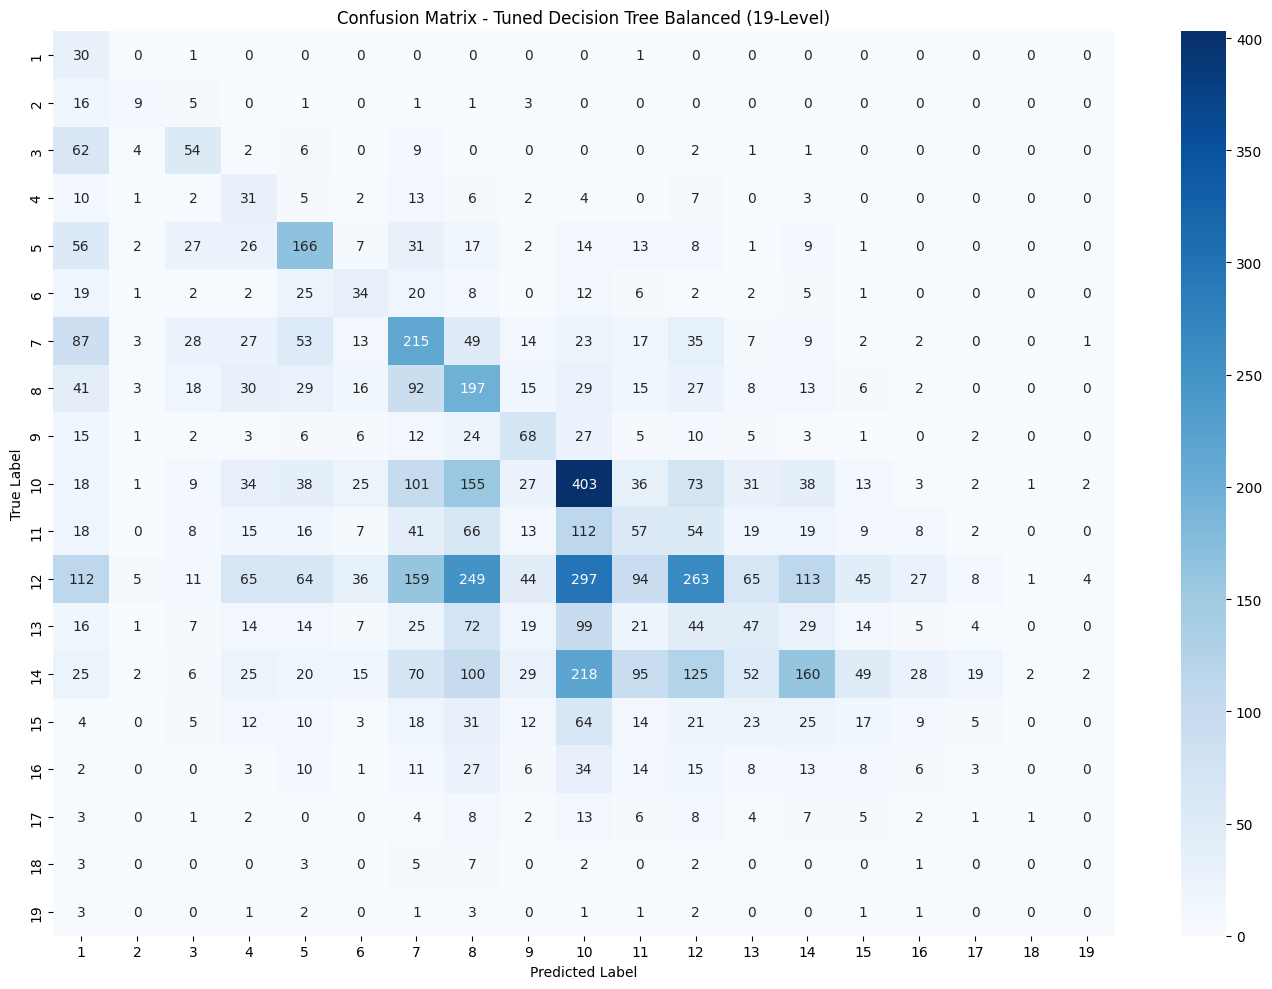

In [24]:
from sklearn.tree import DecisionTreeClassifier

# Train the final tuned model on TRAINING data using the best VALIDATION-selected parameters
dt_tuned_balanced_19 = DecisionTreeClassifier(
    **dt_best_params_19,
    class_weight="balanced"
)

dt_tuned_balanced_19.fit(
    dt_X_train_tfidf,
    dt_y_train_19
)

dt_tuned_balanced_19_test_pred = dt_tuned_balanced_19.predict(dt_X_test_tfidf)

evaluate_dt_model(
    dt_y_test_19,
    dt_tuned_balanced_19_test_pred,
    "Tuned Decision Tree - Balanced (19-Level) - Test Set"
)

plot_confusion_matrix(
    dt_y_test_19,
    dt_tuned_balanced_19_test_pred,
    labels=list(range(1, 20)),
    title="Confusion Matrix - Tuned Decision Tree Balanced (19-Level)"
)

### **Decision Tree Tuned Findings (19-Level)**
#### `class_weight="balanced"`

The balanced model achieved 24.13% accuracy, 37.06% adjacent accuracy, 0.3845 QWK, and 0.1851 Macro F1. Compared with the baseline, accuracy and Macro F1 decreased, while QWK improved. Balancing increased recall for some minority classes but reduced precision, indicating greater sensitivity to minority classes at the cost of overall classification performance.

## **Decision Tree Tuned Model (19-Level)**
### `class_weight=None`

Tuned Decision Tree - None Class Weight (19-Level) - Test Set
Accuracy:                      0.2844
Adjacent Accuracy (±1):        0.4130
Quadratic Weighted Kappa:      0.4062
Macro F1-score:                0.2173
Weighted Precision:            0.2811
Weighted Recall:               0.2844
Mean Absolute Error (MAE):     2.5122
Root Mean Squared Error:       3.5277
R² Score:                      -0.1710

Classification Report:

              precision    recall  f1-score   support

           1       0.53      0.53      0.53        32
           2       0.32      0.25      0.28        36
           3       0.37      0.34      0.35       141
           4       0.14      0.28      0.18        86
           5       0.33      0.43      0.37       380
           6       0.21      0.21      0.21       139
           7       0.24      0.55      0.34       585
           8       0.23      0.40      0.29       541
           9       0.39      0.36      0.37       190
          10       0.31      

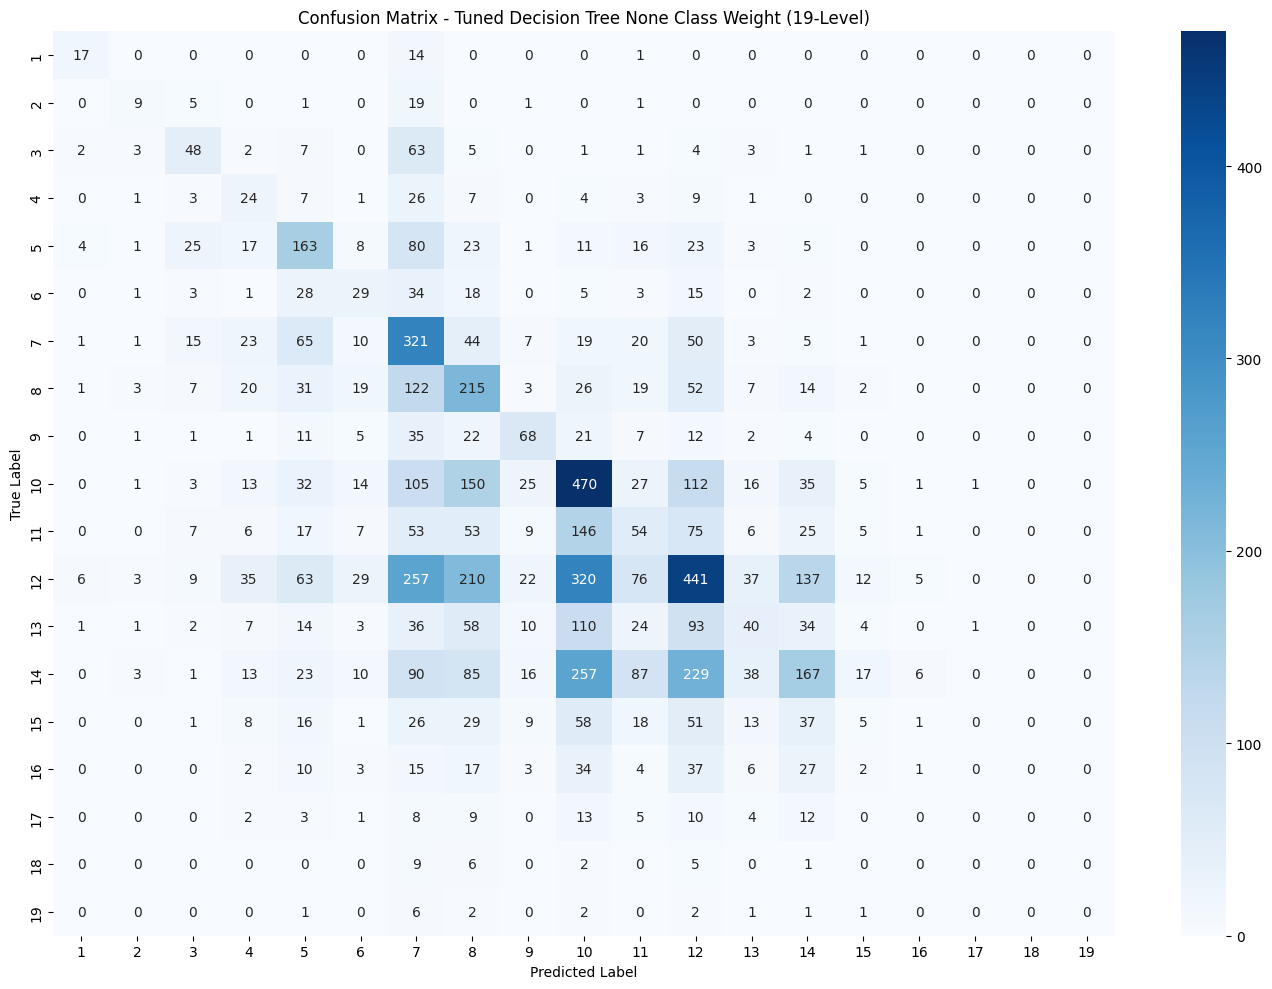

In [25]:
from sklearn.tree import DecisionTreeClassifier

# Same validation-selected parameters; only class_weight changes
dt_tuned_none_19 = DecisionTreeClassifier(
    **dt_best_params_19,
    class_weight=None
)

dt_tuned_none_19.fit(
    dt_X_train_tfidf,
    dt_y_train_19
)

dt_tuned_none_19_test_pred = dt_tuned_none_19.predict(dt_X_test_tfidf)

evaluate_dt_model(
    dt_y_test_19,
    dt_tuned_none_19_test_pred,
    "Tuned Decision Tree - None Class Weight (19-Level) - Test Set"
)

plot_confusion_matrix(
    dt_y_test_19,
    dt_tuned_none_19_test_pred,
    labels=list(range(1, 20)),
    title="Confusion Matrix - Tuned Decision Tree None Class Weight (19-Level)"
)

### **Decision Tree Tuned Findings (19-Level)**
#### `class_weight=None`

The tuned model with class_weight=None achieved 28.44% accuracy, 41.30% adjacent accuracy, 0.4062 QWK, and 0.2173 Macro F1. Its accuracy remained almost identical to the baseline, while QWK improved and MAE decreased from 2.5847 to 2.5122. Overall, tuning improved ordinal agreement and reduced the average prediction error without sacrificing baseline accuracy.

---

## **Decision Tree Baseline Model (5-Level)**

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Baseline Decision Tree (5-Level) - Test Set
Accuracy:                      0.4200
Adjacent Accuracy (±1):        0.7601
Quadratic Weighted Kappa:      0.2745
Macro F1-score:                0.3270
Weighted Precision:            0.4040
Weighted Recall:               0.4200
Mean Absolute Error (MAE):     0.8740
Root Mean Squared Error:       1.2596
R² Score:                      -0.3109

Classification Report:

              precision    recall  f1-score   support

           1       0.47      0.58      0.52      1399
           2       0.42      0.59      0.49      2205
           3       0.38      0.33      0.35      2100
           4       0.42      0.19      0.27      1315
           5   

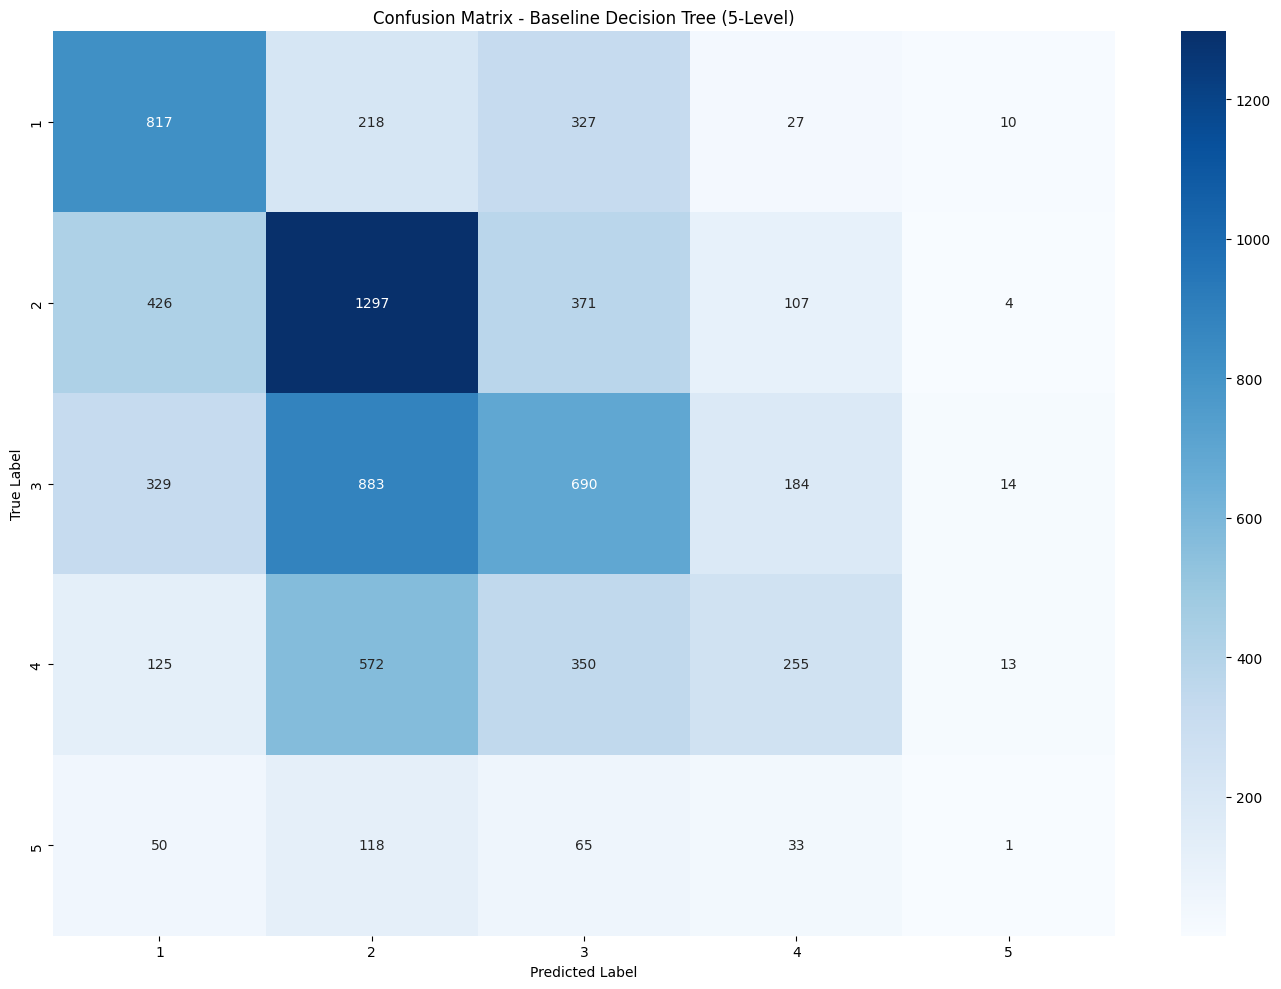

In [26]:
# Define target labels for the 5-level classification task
dt_y_train_5 = filtered_train_df["Readability_Level_5"]
dt_y_dev_5 = filtered_dev_df["Readability_Level_5"]
dt_y_test_5 = filtered_test_df["Readability_Level_5"]

# Fully default baseline
dt_baseline_5 = DecisionTreeClassifier()

print(dt_baseline_5.get_params())

dt_baseline_5.fit(
    dt_X_train_tfidf,
    dt_y_train_5
)

dt_baseline_5_test_pred = dt_baseline_5.predict(dt_X_test_tfidf)

evaluate_dt_model(
    dt_y_test_5,
    dt_baseline_5_test_pred,
    "Baseline Decision Tree (5-Level) - Test Set"
)

plot_confusion_matrix(
    dt_y_test_5,
    dt_baseline_5_test_pred,
    labels=list(range(1, 6)),
    title="Confusion Matrix - Baseline Decision Tree (5-Level)"
)

### **Decision Tree Baseline Findings (5-Level)**

The baseline Decision Tree achieved 42.00% accuracy, 76.01% adjacent accuracy, 0.2745 QWK, and 0.3270 Macro F1. The model performed considerably better on the broader 5-level classification task, but it struggled with class 5, which had almost no successful predictions.

## **Decision Tree Hyperparameter Tuning (5-Level)**

The same focused hyperparameter search space is used for the 5-level task. Hyperparameters are selected using the predefined development set, independently from the 19-level task.

The model is trained on the training split and evaluated on the development split during parameter selection. The test set remains reserved for the final tuned model evaluation.

In [27]:
# Reuse the SAME parameter grid and SAME required GridSearchCV configuration
dt_base = DecisionTreeClassifier()

dt_grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

# Search using the TRAINING SET ONLY
dt_grid_search.fit(
    dt_X_train_tfidf,
    dt_y_train_5
)

dt_best_params_5 = dt_grid_search.best_params_.copy()
dt_best_cv_accuracy_5 = dt_grid_search.best_score_

print("Best Parameters (5-Level):", dt_best_params_5)
print(f"Best 5-Fold CV Accuracy (5-Level): {dt_best_cv_accuracy_5:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters (5-Level): {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10}
Best 5-Fold CV Accuracy (5-Level): 0.4662


## **Decision Tree Tuned Model (5-Level)**
### `class_weight="balanced"`

Tuned Decision Tree - Balanced (5-Level) - Test Set
Accuracy:                      0.4354
Adjacent Accuracy (±1):        0.7650
Quadratic Weighted Kappa:      0.3532
Macro F1-score:                0.3489
Weighted Precision:            0.4232
Weighted Recall:               0.4354
Mean Absolute Error (MAE):     0.8677
Root Mean Squared Error:       1.2780
R² Score:                      -0.3494

Classification Report:

              precision    recall  f1-score   support

           1       0.45      0.80      0.58      1399
           2       0.45      0.54      0.49      2205
           3       0.43      0.26      0.32      2100
           4       0.40      0.24      0.30      1315
           5       0.08      0.04      0.05       267

    accuracy                           0.44      7286
   macro avg       0.36      0.38      0.35      7286
weighted avg       0.42      0.44      0.41      7286



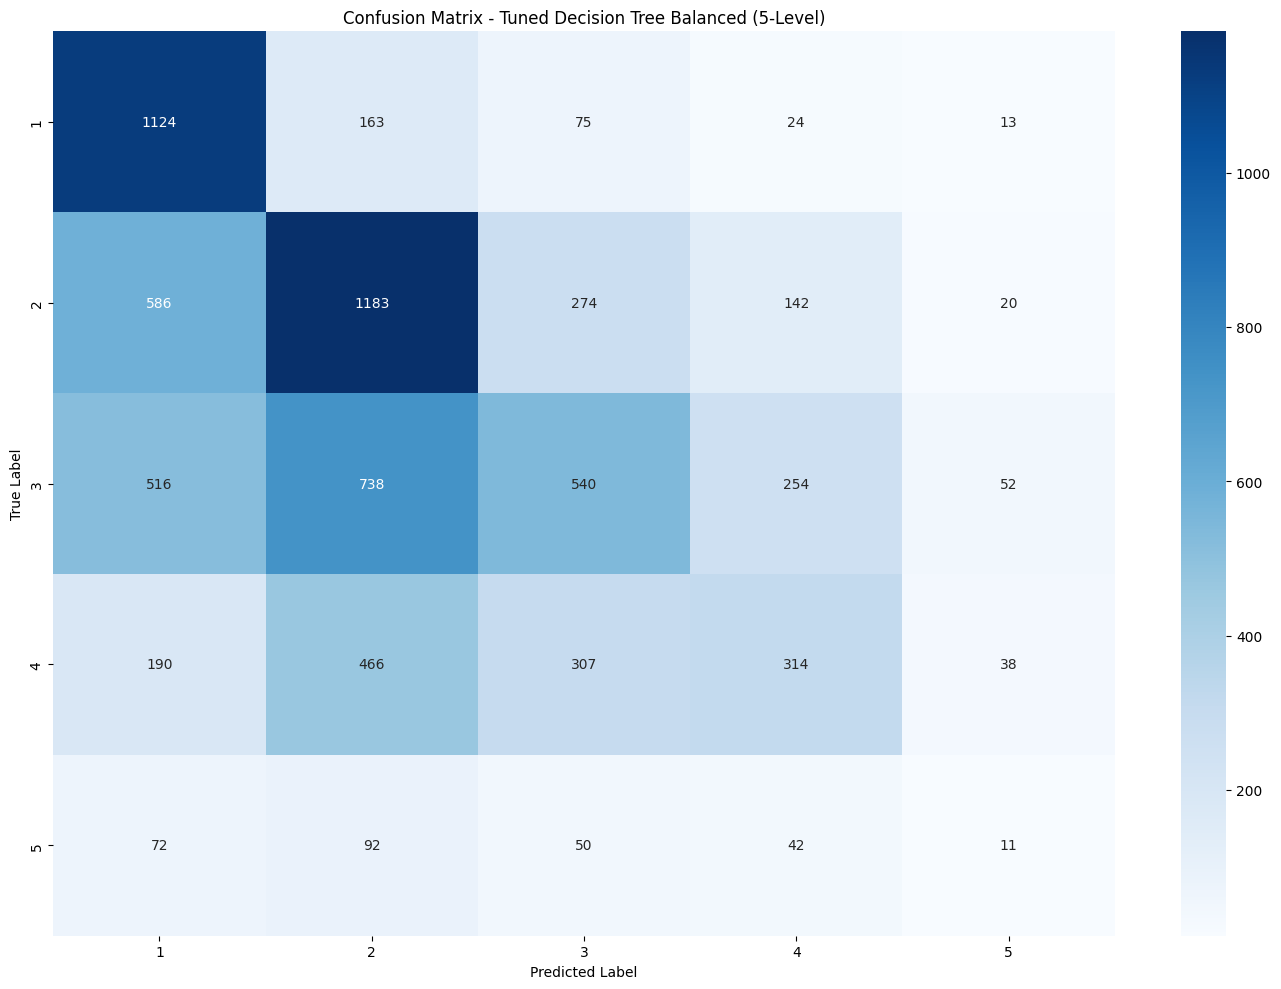

In [28]:
from sklearn.tree import DecisionTreeClassifier

dt_tuned_balanced_5 = DecisionTreeClassifier(
    **dt_best_params_5,
    class_weight="balanced"
)

dt_tuned_balanced_5.fit(
    dt_X_train_tfidf,
    dt_y_train_5
)

dt_tuned_balanced_5_test_pred = dt_tuned_balanced_5.predict(dt_X_test_tfidf)

evaluate_dt_model(
    dt_y_test_5,
    dt_tuned_balanced_5_test_pred,
    "Tuned Decision Tree - Balanced (5-Level) - Test Set"
)

plot_confusion_matrix(
    dt_y_test_5,
    dt_tuned_balanced_5_test_pred,
    labels=list(range(1, 6)),
    title="Confusion Matrix - Tuned Decision Tree Balanced (5-Level)"
)

### **Decision Tree Tuned Findings (5-Level)**
#### `class_weight="balanced"`

The balanced model achieved 43.54% accuracy, 76.50% adjacent accuracy, 0.3532 QWK, and 0.3489 Macro F1. Compared with the baseline, accuracy, QWK, and Macro F1 improved. Balancing also provided some improvement in detecting class 5, although its performance remained weak.

## **Decision Tree Tuned Model (5-Level)**
### `class_weight=None`

Tuned Decision Tree - None Class Weight (5-Level) - Test Set
Accuracy:                      0.4382
Adjacent Accuracy (±1):        0.7772
Quadratic Weighted Kappa:      0.3348
Macro F1-score:                0.3328
Weighted Precision:            0.4162
Weighted Recall:               0.4382
Mean Absolute Error (MAE):     0.8437
Root Mean Squared Error:       1.2416
R² Score:                      -0.2735

Classification Report:

              precision    recall  f1-score   support

           1       0.48      0.76      0.59      1399
           2       0.42      0.60      0.50      2205
           3       0.43      0.27      0.33      2100
           4       0.40      0.18      0.25      1315
           5       0.00      0.00      0.00       267

    accuracy                           0.44      7286
   macro avg       0.35      0.36      0.33      7286
weighted avg       0.42      0.44      0.40      7286



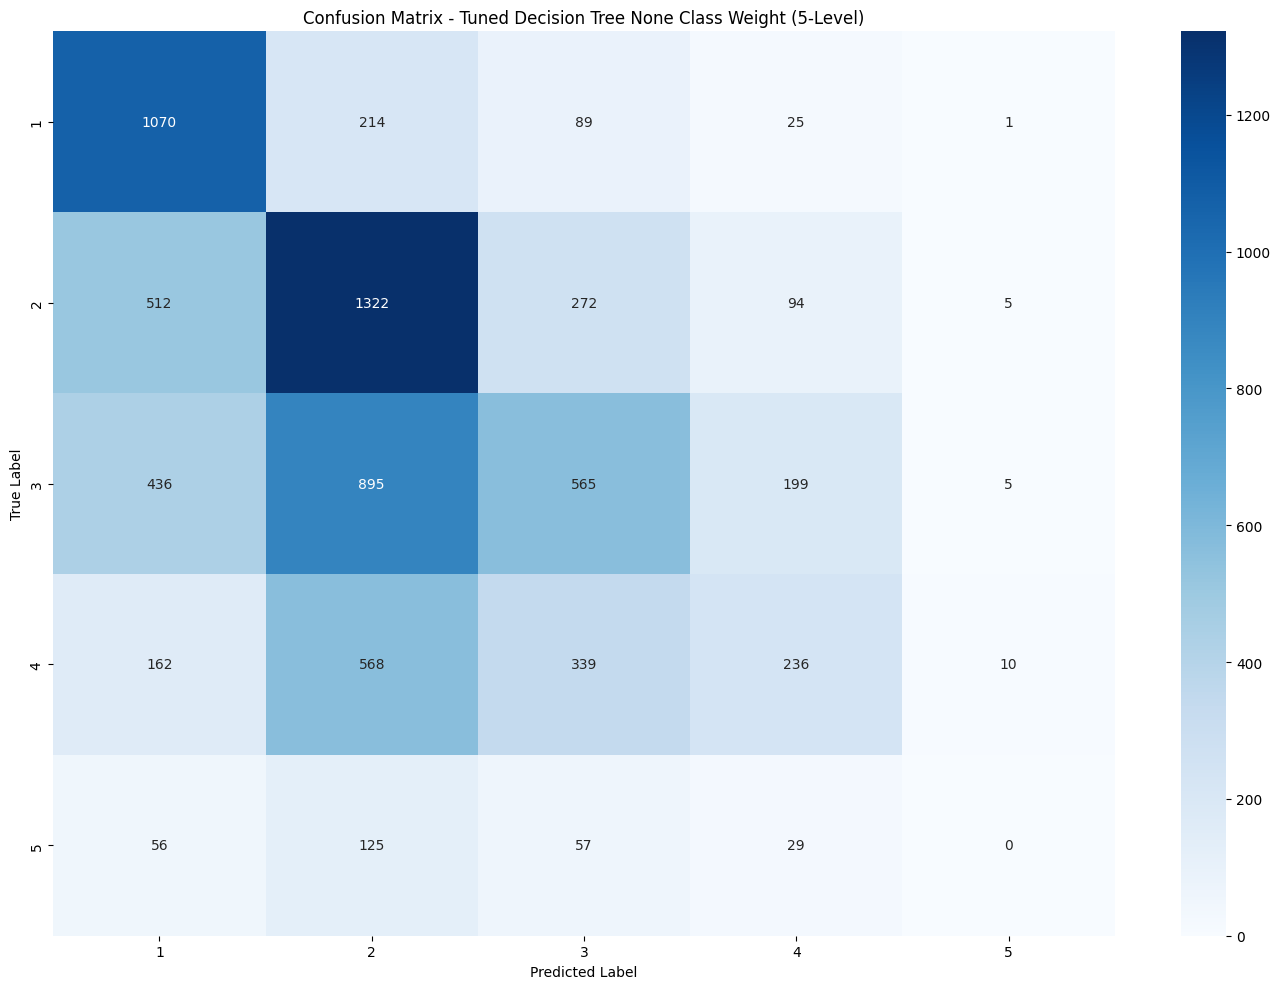

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt_tuned_none_5 = DecisionTreeClassifier(
    **dt_best_params_5,
    class_weight=None
)

dt_tuned_none_5.fit(
    dt_X_train_tfidf,
    dt_y_train_5
)

dt_tuned_none_5_test_pred = dt_tuned_none_5.predict(dt_X_test_tfidf)

evaluate_dt_model(
    dt_y_test_5,
    dt_tuned_none_5_test_pred,
    "Tuned Decision Tree - None Class Weight (5-Level) - Test Set"
)

plot_confusion_matrix(
    dt_y_test_5,
    dt_tuned_none_5_test_pred,
    labels=list(range(1, 6)),
    title="Confusion Matrix - Tuned Decision Tree None Class Weight (5-Level)"
)

### **Decision Tree Tuned Findings (5-Level)**
#### `class_weight=" None"`

The tuned model with class_weight=None achieved 43.82% accuracy, 77.72% adjacent accuracy, 0.3348 QWK, and 0.3328 Macro F1. It achieved the highest accuracy and adjacent accuracy and reduced MAE to 0.8437. However, it failed to identify class 5.

# **Comparison Between 19-Level and 5-Level Results**


| Experiment                              |   Accuracy | Adjacent Accuracy (±1) |        QWK |   Macro F1 |        MAE |       RMSE |
| --------------------------------------- | ---------: | ---------------------: | ---------: | ---------: | ---------: | ---------: |
| Baseline Decision Tree - 19 Level       |     0.2845 |                 0.4197 |     0.3358 |     0.2290 |     2.5847 |     3.6810 |
| Tuned Decision Tree Balanced - 19 Level |     0.2413 |                 0.3706 |     0.3845 |     0.1851 |     3.0150 |     4.2110 |
| Tuned Decision Tree None - 19 Level     |     0.2844 |                 0.4130 | **0.4062** |     0.2173 | **2.5122** |     3.5260 |
| Baseline Decision Tree - 5 Level        |     0.4200 |                 0.7601 |     0.2745 |     0.3270 |     0.8740 |     1.2530 |
| Tuned Decision Tree Balanced - 5 Level  |     0.4354 |                 0.7650 | **0.3532** | **0.3489** |     0.8677 |     1.2310 |
| Tuned Decision Tree None - 5 Level      | **0.4382** |             **0.7772** |     0.3348 |     0.3328 | **0.8437** | **1.2110** |



## **Decision Tree Performance Comparison Level 19 (Baseline vs Tuned vs Paper Results)**


| Model                                    |      Acc19 | ±1 Accuracy |      MAE |       QWK |
| ---------------------------------------- | ---------: | ----------: | -------: | --------: |
| **Paper Decision Tree (Word)**           |      27.2% |       41.2% | **2.50** | **44.2%** |
| **Our Decision Tree (Baseline)**         | **28.45%** |  **41.97%** |     2.58 |    33.58% |
| **Our Decision Tree (Tuned – Balanced)** |     24.13% |      37.06% |     3.02 |    38.45% |
| **Our Decision Tree (Tuned – None)**     |     28.44% |      41.30% |     2.51 |    40.62% |


##**Decision Tree Performance Comparison Level 5 (Baseline vs Tuned)**

| Model                                      |       Acc5 | ±1 Accuracy |      MAE |        QWK |
| ------------------------------------------ | ---------: | ----------: | -------: | ---------: |
| **Our Decision Tree (Baseline – 5 Level)** |     42.00% |      76.01% |     0.87 |     27.45% |
| **Our Decision Tree (Tuned – Balanced)**   |     43.54% |      76.50% |     0.87 | **35.32%** |
| **Our Decision Tree (Tuned – None)**       | **43.82%** |  **77.72%** | **0.84** |     33.48% |


##**Decision Tree Performance Comparison (Paper vs Our Model – 19-Level & 5-Level)**

| Model                                    | Level |        Acc | ±1 Accuracy |      MAE |        QWK |
| ---------------------------------------- | ----: | ---------: | ----------: | -------: | ---------: |
| **Paper Decision Tree (Word)**           |    19 |      27.2% |       41.2% | **2.50** |  **44.2%** |
| **Our Decision Tree (Baseline)**         |    19 | **28.45%** |  **41.97%** |     2.58 |     33.58% |
| **Our Decision Tree (Tuned – Balanced)** |    19 |     24.13% |      37.06% |     3.02 |     38.45% |
| **Our Decision Tree (Tuned – None)**     |    19 |     28.44% |      41.30% |     2.51 |     40.62% |
| **Our Decision Tree (Baseline)**         |     5 |     42.00% |      76.01% |     0.87 |     27.45% |
| **Our Decision Tree (Tuned – Balanced)** |     5 |     43.54% |      76.50% |     0.87 | **35.32%** |
| **Our Decision Tree (Tuned – None)**     |     5 | **43.82%** |  **77.72%** | **0.84** |     33.48% |
